# Lunar Laser Communication: A Link Budget Checked Against Reality

Why does deep-space communication move to photonics, and roughly how
does a first-principles link budget compare to a real demonstration?
The one real, public reference point used here: NASA's Lunar Laser
Communication Demonstration (LLCD), flown on LADEE in 2013, publicly
demonstrated a **622 Mbps optical downlink from lunar distance** -- the
first such link to/from the Moon. This notebook does NOT claim to know
LLCD's actual transmitter power, aperture, or coding scheme; illustrative
small-terminal parameters are used and labeled as such throughout, then
checked for landing in a physically sensible regime relative to that one
real public figure. Reuses `dgs.quantum_internet_link_budget`'s
diffraction-limited free-space loss model directly rather than
reimplementing it. Engine: `dgs/lunar_laser_communication.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import lunar_laser_communication as llc

print(f'LLCD public downlink figure: {llc.LLCD_PUBLIC_DOWNLINK_BPS/1e6:.0f} Mbps (2013, publicly documented)')


LLCD public downlink figure: 622 Mbps (2013, publicly documented)


## 1. Earth-Moon Light Time

$$t = \frac{d}{c}$$

checked at perigee, mean distance, and apogee -- the ~1.28s figure widely
cited for Earth-Moon signal delay.


In [2]:
for name, d in [('perigee', llc.MOON_PERIGEE_M), ('mean', llc.MOON_MEAN_DISTANCE_M), ('apogee', llc.MOON_APOGEE_M)]:
    t = llc.one_way_light_time_s(d)
    print(f'{name:8s}: {d/1e3:>7.0f} km  ->  {t:.3f} s one-way light time')


perigee :  363300 km  ->  1.212 s one-way light time
mean    :  384400 km  ->  1.282 s one-way light time
apogee  :  405500 km  ->  1.353 s one-way light time


## 2. The Link Budget: Diffraction-Limited Geometric Loss

Reusing `dgs.quantum_internet_link_budget.free_space_geometric_loss_db`
directly -- the SAME diffraction physics (Rayleigh-criterion beam
divergence, power-law-in-distance loss) already verified in that module,
now applied at lunar rather than LEO-satellite distance.


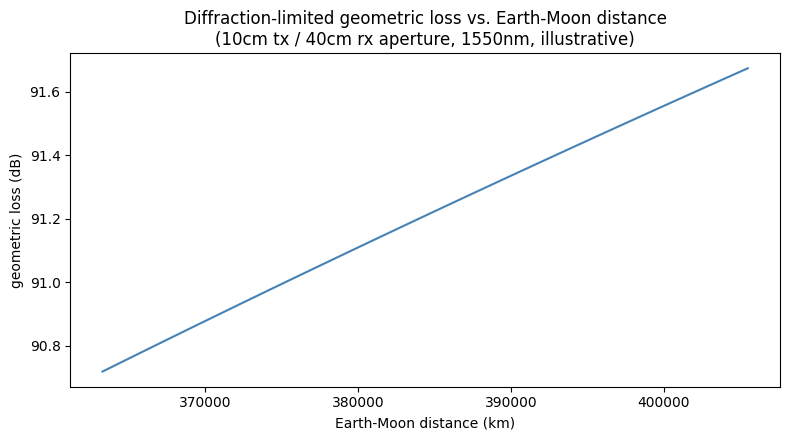

In [3]:
distances_km = np.linspace(llc.MOON_PERIGEE_M, llc.MOON_APOGEE_M, 50) / 1e3
losses_db = [llc.received_power_w(2.0, d*1e3, 1550e-9, 0.1, 0.4)[1] for d in distances_km]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(distances_km, losses_db, color='steelblue')
ax.set_xlabel('Earth-Moon distance (km)'); ax.set_ylabel('geometric loss (dB)')
ax.set_title('Diffraction-limited geometric loss vs. Earth-Moon distance\n(10cm tx / 40cm rx aperture, 1550nm, illustrative)')
plt.tight_layout()
plt.savefig('lunar_laser_comm_loss_vs_distance.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Idealized Photon-Limited Rate Ceiling vs. the Public LLCD Figure

The idealized ceiling (perfect detection, zero coding overhead) should
sit ABOVE the real demonstrated rate -- a real system needs additional
photons per bit for reliable detection, coding overhead, and margin --
but not absurdly above it, which would signal a modeling error rather
than a reasonable idealization gap.


In [4]:
check = llc.verify_against_llcd_public_figure()
print(f"geometric loss: {check['geometric_loss_db']:.1f} dB")
print(f"received power: {check['received_power_w']:.3e} W")
print(f"idealized rate ceiling: {check['idealized_ceiling_bps']/1e6:.1f} Mbps")
print(f"public LLCD (2013) downlink: {check['llcd_public_downlink_bps']/1e6:.0f} Mbps")
print(f"ceiling / LLCD ratio: {check['ratio_ceiling_to_llcd']:.2f}x")
print(f"ceiling above real demonstrated rate: {check['ceiling_above_real_rate']}")
print(f"same order-of-magnitude regime (1x-100x): {check['same_order_of_magnitude_regime']}")


geometric loss: 91.2 dB
received power: 3.803e-10 W
idealized rate ceiling: 1483.8 Mbps
public LLCD (2013) downlink: 622 Mbps
ceiling / LLCD ratio: 2.39x
ceiling above real demonstrated rate: True
same order-of-magnitude regime (1x-100x): True


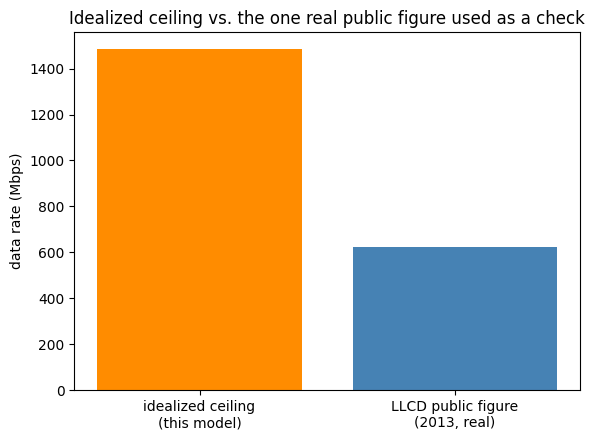

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ['idealized ceiling\n(this model)', 'LLCD public figure\n(2013, real)']
values = [check['idealized_ceiling_bps']/1e6, check['llcd_public_downlink_bps']/1e6]
ax.bar(labels, values, color=['darkorange', 'steelblue'])
ax.set_ylabel('data rate (Mbps)')
ax.set_title('Idealized ceiling vs. the one real public figure used as a check')
plt.tight_layout()
plt.savefig('lunar_laser_comm_rate_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Why Optical, Not RF: A Same-Aperture Comparison

Holding aperture fixed and only changing wavelength isolates the real
physical reason deep-space links move to photonics: diffraction
divergence scales with wavelength, and optical wavelengths are ~1000x
shorter than Ka-band RF. This is NOT a claim that real RF deep-space
terminals use a small aperture -- real systems (NASA's Deep Space
Network 34m/70m dishes) compensate with much larger apertures.


In [6]:
rf_compare = llc.compare_optical_vs_rf_geometric_loss(llc.MOON_MEAN_DISTANCE_M, aperture_m=0.1)
print(f"optical (1550nm) loss: {rf_compare['optical_loss_db']:.1f} dB")
print(f"RF (Ka-band, 32GHz) loss: {rf_compare['rf_loss_db']:.1f} dB")
print(f"optical advantage: {rf_compare['optical_advantage_db']:.1f} dB")
print(f"optical wins: {rf_compare['optical_wins']}")


optical (1550nm) loss: 103.3 dB
RF (Ka-band, 32GHz) loss: 178.9 dB
optical advantage: 75.7 dB
optical wins: True


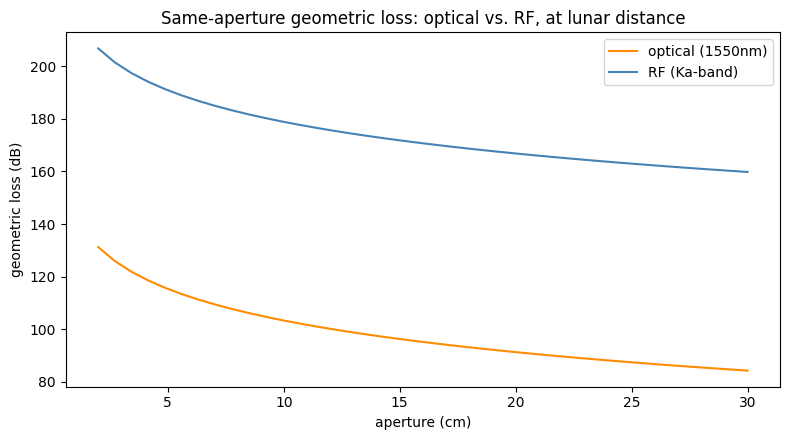

In [7]:
apertures_m = np.linspace(0.02, 0.3, 40)
opt_losses = [llc.compare_optical_vs_rf_geometric_loss(llc.MOON_MEAN_DISTANCE_M, a)['optical_loss_db'] for a in apertures_m]
rf_losses = [llc.compare_optical_vs_rf_geometric_loss(llc.MOON_MEAN_DISTANCE_M, a)['rf_loss_db'] for a in apertures_m]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(apertures_m*100, opt_losses, label='optical (1550nm)', color='darkorange')
ax.plot(apertures_m*100, rf_losses, label='RF (Ka-band)', color='steelblue')
ax.set_xlabel('aperture (cm)'); ax.set_ylabel('geometric loss (dB)')
ax.set_title('Same-aperture geometric loss: optical vs. RF, at lunar distance')
ax.legend()
plt.tight_layout()
plt.savefig('lunar_laser_comm_optical_vs_rf.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. A Real Bug This Module's Development Caught

`compare_optical_vs_rf_geometric_loss`'s first version returned
`optical_loss_db < rf_loss_db` directly as the `optical_wins` value. The
comparison is between two `np.float64` values (from
`free_space_geometric_loss_db`'s `np.log10` call), so the result is
`numpy.bool_`, not a Python `bool`. The VALUE was correct (`True`), but
`numpy.bool_(True) is True` evaluates to `False` -- numpy scalars are
never identical to Python's `True` singleton. This module's own test
asserting `rf_compare["optical_wins"] is True` caught it immediately;
the fix wraps the return values in explicit `bool()`/`float()` casts.


In [8]:
import numpy as np
np_true = np.bool_(True)
print(f'np_true == True:  {np_true == True}')
print(f'np_true is True:  {np_true is True}')
print('-> value-equal but not identity-equal; `is True` checks are the exact place this bites.')


np_true == True:  True
np_true is True:  False
-> value-equal but not identity-equal; `is True` checks are the exact place this bites.


## 6. Engineering Interpretation

- Section 3's ~2.4x gap between the idealized ceiling and the real LLCD
  rate is a physically sensible outcome, not a coincidence to force: a
  real optical downlink needs several photons per bit for reliable
  pulse-position-modulation detection against background noise, plus
  forward error correction overhead -- both of which this idealized
  model deliberately omits to isolate the pure geometric/photon-budget
  physics.
- Section 4's ~76 dB same-aperture advantage is the actual physics
  argument for why real programs (LLCD, LCRD, Artemis's optical
  terminal work) invest in photonics for deep-space links: at any fixed
  aperture budget, optical wavelengths buy dramatically more link
  margin than RF, even though real RF systems partially compensate with
  much larger dish apertures.
- Section 5's bug is a small one in isolation, but it is exactly the
  kind of silent failure mode `is True`/`is False` checks are meant to
  surface: a numerically correct computation that fails an identity
  check used elsewhere in the codebase (test assertions, dict-based
  control flow) would otherwise pass unnoticed until it broke something
  downstream.


## 7. Research Discussion

- This module and `dgs.quantum_internet_link_budget` share the exact
  same diffraction-loss physics (imported directly, not reimplemented)
  applied at two very different distance regimes (LEO satellite vs.
  lunar) -- a genuine instance of one physical model generalizing across
  scales without modification.
- `dgs.rocket_equation_orbital_mechanics`'s Hohmann transfer and this
  module's light-time calculation both concern the SAME Earth-Moon
  distance regime from complementary angles (getting there vs.
  communicating once there) -- a natural pairing for a combined mission
  architecture discussion.
- A genuinely open question this module doesn't resolve: how does
  pointing/tracking accuracy (keeping a diffraction-limited beam aimed
  at a receiver across a 1.28s round-trip light delay) affect the
  achievable link budget in practice -- that's a control-systems problem
  layered on top of the pure link-budget physics modeled here.


## 8. Possible Experiments

1. Add a pulse-position-modulation (PPM) photon-efficiency model (the
   real technique LLCD used) instead of the idealized "1 photon = X
   bits" ceiling, and see how much closer the modeled rate lands to the
   real 622 Mbps figure.
2. Sweep aperture size for BOTH transmitter and receiver independently
   (this module currently only sweeps one at a time in the notebook) to
   map the full 2D trade space for a fixed target data rate.
3. Extend `compare_optical_vs_rf_geometric_loss` to realistic DSN-scale
   RF apertures (34m/70m) and confirm the optical advantage narrows (but
   does it fully close?) once RF is allowed a realistically large dish.


## 9. Future Improvements

- `received_power_w`'s `extra_loss_db` lumps pointing loss, optical
  train loss, and atmospheric (for a ground station) loss into one
  fixed number; a real link budget breaks these out separately since
  each has different physical drivers and design levers.
- `idealized_photon_limited_rate_bps` has no noise/background-photon
  model (solar background, detector dark counts) -- a real photon-
  counting receiver's achievable rate is bounded by signal-to-background
  ratio, not just raw photon arrival rate, which this idealized ceiling
  doesn't capture.
